## Training YOLOv10 model to classify Diseases in strawberry crops


### Before starting
Let's make sure that we have access to GPU. We can use nvidia-smi command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`. Run the following command to verify if a GPU is assigned.

In [ ]:
!nvidia-smi

Sat Apr 19 09:09:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Mounting google drive

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Import dataset from a roblofow project in notebook


In [ ]:
!pip install roboflow
!pip install ultralytics

from roboflow import Roboflow
rf = Roboflow(api_key="Smzko2azI2R3w312n6nc")
project = rf.workspace("strawberry-disease").project("strawberry-disease-detection-dataset")
version = project.version(4)
dataset = version.download("yolov9")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.2/85.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 130.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.8/978.8 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 121.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.2 MB/s eta 0:00:0


Extracting Dataset Version Zip to Strawberry-Disease-Detection-Dataset-4 in yolov9:: 100%|██████████| 9808/9808 [00:01<00:00, 6957.30it/s]


2. Upload YOLOv10 model from ultralytics library

In [ ]:
from ultralytics import YOLO

# Load YOLOv10n model from scratch
model = YOLO("yolov10n.pt")

# Train the model
model.train(data="/content/Strawberry-Disease-Detection-Dataset-4/data.yaml", epochs=100, imgsz=640)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.59M/5.59M [00:00<00:00, 69.1MB/s]


Ultralytics 8.3.28 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
engine/trainer: task=detect, mode=train, model=yolov10n.pt, data=/content/Strawberry-Disease-Detection-Dataset-4/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False

100%|██████████| 755k/755k [00:00<00:00, 14.6MB/s]


Overriding model.yaml nc=80 with nc=7

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1      9856  ultralytics.nn.modules.block.SCDown          [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1     36096  ultralytics

...

                   all        988       2275      0.955      0.922      0.964      0.852



100 epochs completed in 0.969 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 5.8MB
Optimizer stripped from runs/detect/train/weights/best.pt, 5.8MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.28 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
YOLOv10n summary (fused): 285 layers, 2,697,146 parameters, 0 gradients, 8.2 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 31/31 [00:05<00:00,  6.01it/s]


                   all        988       2275      0.957      0.921      0.964      0.852
      Angular Leafspot        186        232      0.991      0.978      0.989      0.904
 Anthracnose Fruit Rot         45         71      0.967      0.827      0.931      0.722
        Blossom Blight         83        117      0.987      0.966      0.994      0.896
             Gray Mold        176        215      0.953      0.898      0.936      0.754
             Leaf Spot        230        808      0.963      0.955       0.98      0.942
  Powdery Mildew Fruit         55        134      0.886       0.91      0.948      0.834
   Powdery Mildew Leaf        213        698      0.948      0.912       0.97      0.913
Speed: 0.1ms preprocess, 0.7ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x786b50b14370>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

Save results to google drive

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import locale
import shutil
import os

# Set the locale to UTF-8
locale.setlocale(locale.LC_ALL, 'C.UTF-8')

# Define source and destination paths
source_path = '/content/runs'
destination_path = '/content/drive/MyDrive/Colab Notebooks/runs'
# Ensure the destination directory exists
os.makedirs(destination_path, exist_ok=True)

# Copy the results to Google Drive
shutil.copytree(source_path, destination_path, dirs_exist_ok=True)

FileNotFoundError: [Errno 2] No such file or directory: '/content/runs'

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


0: 640x640 1 Angular Leafspot, 16.2ms
Speed: 7.8ms preprocess, 16.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict2


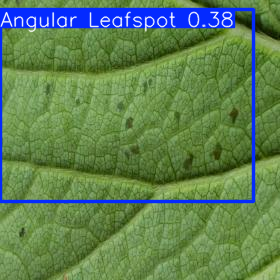

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("/content/drive/MyDrive/Colab Notebooks/runs/detect/train/weights/best.pt")

# Run batched inference on a list of images
results = model(["/content/Strawberry-Disease-Detection-Dataset-4/test/images/angular_leafspot142_jpg.rf.726766ea0cc145d692b15d38a6e5b219.jpg"], save=True, show=True)  # return a list of Results objects
results[0].show()

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("/content/drive/MyDrive/Colab Notebooks/runs/detect/train/weights/best.pt")

# Run batched inference on a list of images
results = model(["/content/Strawberry-Disease-Detection-Dataset-4/test/images/gray_mold107_jpg.rf.bf498ed96895836eec498ccc70dfd906.jpg"], save=True, show=True)  # return a list of Results objects

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


0: 640x640 1 Gray Mold, 11.9ms
Speed: 3.0ms preprocess, 11.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict3


WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


0: 640x640 3 Leaf Spots, 8.8ms
Speed: 3.3ms preprocess, 8.8ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict3


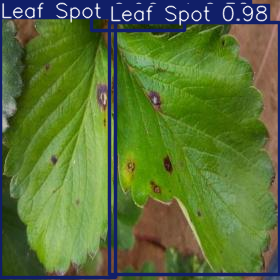

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("/content/drive/MyDrive/Colab Notebooks/runs/detect/train/weights/best.pt")

# Run batched inference on a list of images
results = model(["/content/Strawberry-Disease-Detection-Dataset-4/test/images/leaf_spot104.rf.5047daf02dceac56efc524b709a7edd8.jpg"], save=True, show=True)  # return a list of Results objects
results[0].show()

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


0: 640x640 2 Powdery Mildew Fruits, 35.4ms
Speed: 5.4ms preprocess, 35.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict4


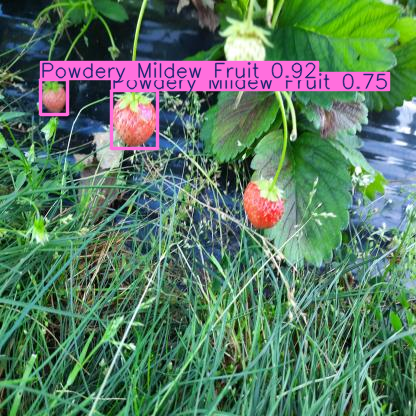

In [ ]:

from ultralytics import YOLO
# Load a model
model = YOLO("/content/drive/MyDrive/Colab Notebooks/runs/detect/train/weights/best.pt")

# Run batched inference on a list of images
results = model(["/content/drive/MyDrive/Colab Notebooks/data-set-some/13_jpg.rf.4b89b07bc37955eecb67ce68d1b09533.jpg"], save=True, show=True)  # return a list of Results objects
results[0].show()

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


0: 640x640 1 Gray Mold, 8.1ms
Speed: 2.5ms preprocess, 8.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict5


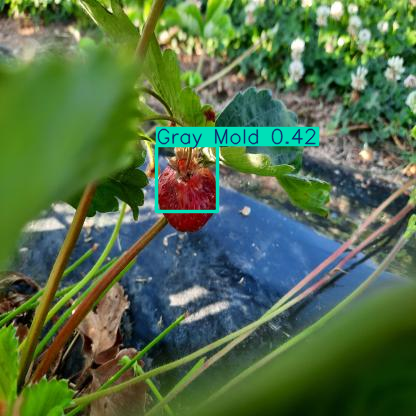

In [ ]:
# Load a model
model = YOLO("/content/drive/MyDrive/Colab Notebooks/runs/detect/train/weights/best.pt")

# Run batched inference on a list of images
results = model(["/content/drive/MyDrive/Colab Notebooks/data-set-some/8_jpg.rf.73cdbffba2442ba214972fdb734e35af.jpg"], save=True, show=True)  # return a list of Results objects
results[0].show()

## SAM SEGMENTATION

In [ ]:
# Process results list
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    print(boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([3.], device='cuda:0')
conf: tensor([0.4245], device='cuda:0')
data: tensor([[156.0712, 145.5492, 217.8495, 211.6233,   0.4245,   3.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (416, 416)
shape: torch.Size([1, 6])
xywh: tensor([[186.9603, 178.5863,  61.7783,  66.0741]], device='cuda:0')
xywhn: tensor([[0.4494, 0.4293, 0.1485, 0.1588]], device='cuda:0')
xyxy: tensor([[156.0712, 145.5492, 217.8495, 211.6233]], device='cuda:0')
xyxyn: tensor([[0.3752, 0.3499, 0.5237, 0.5087]], device='cuda:0')


100%|██████████| 154M/154M [00:02<00:00, 54.6MB/s]


Results saved to runs/segment/predict


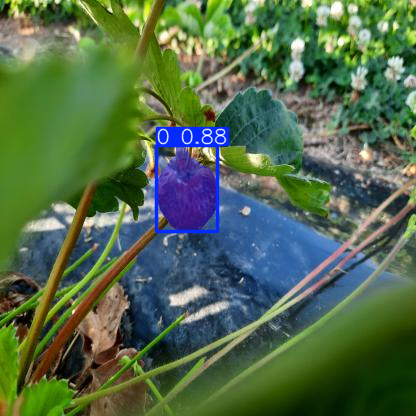

In [ ]:
from ultralytics import SAM

# Load the YOLO model
#yolo_model = YOLO("/content/runs/detect/train/weights/best.pt")  # pretrained YOLO model

# Run batched inference on a list of images
#results = yolo_model("/content/meningioma_3.jpg")  # return a list of Results objects

# Load the SAM model
#sam_model = SAM("/content/drive/MyDrive/Colab Notebooks/runs/detect/train/weights/fine_tuned_sam2_strawberry3000.torch")

# Process results list
sam_model = SAM("sam2_b.pt")

for result in results:
     class_ids = result.boxes.cls.int().tolist()  # noqa
     if len(class_ids):
         boxes = result.boxes.xyxy  # Boxes object for bbox outputs
         sam_results = sam_model(result.orig_img, bboxes=boxes, verbose=False, save=True, device=0)
sam_results[0].show()